# Lumber Price Forecasting with Non-Time-Series Machine Learning

This notebook builds a tabular machine learning pipeline for forecasting US lumber prices using **yfinance** lumber futures data. The focus is on **non-time-series models** such as linear regression, random forests, gradient boosting, and support vector regression.

## Objective

Predict the future lumber closing price at a chosen forecast horizon using historical market data, engineered lag features, rolling statistics, momentum, volatility, and calendar information.

## Workflow

1. Install and import dependencies.
2. Download lumber futures data from yfinance.
3. Optionally merge external macro or trade features.
4. Clean and validate the dataset.
5. Create tabular features and a future-price target.
6. Split the data chronologically.
7. Train and compare several non-time-series regression models.
8. Tune selected models with time-aware cross-validation.
9. Evaluate forecast accuracy and directional performance.
10. Interpret the best model and export artifacts.

## 1. Install and Import Dependencies

This section installs any missing libraries and configures the notebook environment for reproducible analysis.

In [25]:
%pip install -q yfinance scikit-learn seaborn joblib

Note: you may need to restart the kernel to use updated packages.


In [26]:
from __future__ import annotations

import json
import warnings
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import yfinance as yf
from pandas.tseries.offsets import BDay
from sklearn.compose import ColumnTransformer
from sklearn.dummy import DummyRegressor
from sklearn.ensemble import GradientBoostingRegressor, RandomForestRegressor
from sklearn.impute import SimpleImputer
from sklearn.inspection import permutation_importance
from sklearn.linear_model import Lasso, LinearRegression, Ridge
from sklearn.metrics import mean_absolute_error, mean_absolute_percentage_error, mean_squared_error, r2_score
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV, TimeSeriesSplit
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVR

warnings.filterwarnings("ignore")

RANDOM_STATE = 42
FORECAST_HORIZON = 5
ARTIFACTS_DIR = Path("artifacts")
ARTIFACTS_DIR.mkdir(exist_ok=True)

plt.style.use("seaborn-v0_8-whitegrid")
sns.set_theme(style="whitegrid", context="talk")
np.random.seed(RANDOM_STATE)

pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 160)

print(f"Forecast horizon: {FORECAST_HORIZON} trading days")

Forecast horizon: 5 trading days


## 2. Download Lumber Price Data from yfinance

The primary source is lumber futures from yfinance. The code tries multiple likely ticker symbols and keeps the first one that returns valid price history.

Using ticker: LBS=F
Price             Open   High         Low       Close   Adj Close  Volume
Date                                                                     
2023-05-09  357.000000  357.0  339.000000  344.000000  344.000000      38
2023-05-10  345.000000  355.0  342.600006  348.899994  348.899994      54
2023-05-11  338.000000  349.5  326.600006  345.000000  345.000000      51
2023-05-12  345.500000  360.0  339.000000  339.000000  339.000000      73
2023-05-15  337.100006  344.0  335.000000  344.000000  344.000000      73


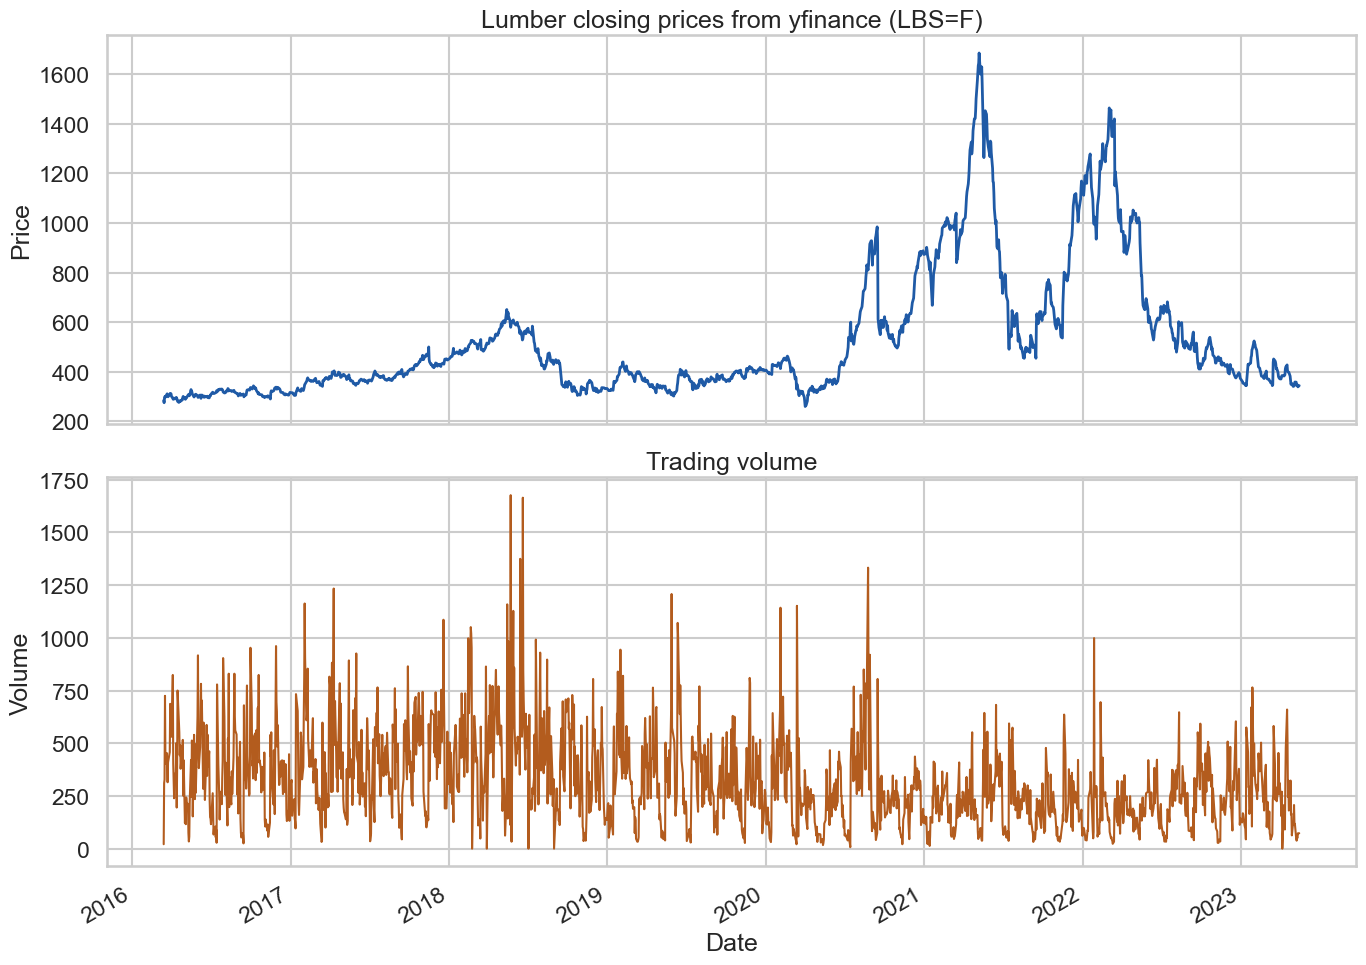

In [27]:
def download_lumber_prices(period: str = "10y", interval: str = "1d") -> tuple[pd.DataFrame, str]:
    tickers_to_try = ["LBS=F", "LB=F"]

    for ticker in tickers_to_try:
        data = yf.download(ticker, period=period, interval=interval, auto_adjust=False, progress=False)
        if data.empty:
            continue

        if isinstance(data.columns, pd.MultiIndex):
            data.columns = data.columns.get_level_values(0)

        required_columns = ["Open", "High", "Low", "Close", "Adj Close", "Volume"]
        available_columns = [column for column in required_columns if column in data.columns]
        frame = data[available_columns].copy()
        frame.index = pd.to_datetime(frame.index)
        frame.index.name = "Date"
        frame = frame.sort_index()
        return frame, ticker

    raise ValueError("No valid lumber ticker returned data from yfinance. Try a different ticker or date range.")


raw_prices, selected_ticker = download_lumber_prices()
print(f"Using ticker: {selected_ticker}")
print(raw_prices.tail())

fig, axes = plt.subplots(2, 1, figsize=(14, 10), sharex=True)
raw_prices["Close"].plot(ax=axes[0], color="#1f5aa6", linewidth=2)
axes[0].set_title(f"Lumber closing prices from yfinance ({selected_ticker})")
axes[0].set_ylabel("Price")

raw_prices["Volume"].plot(ax=axes[1], color="#b35c1e", linewidth=1.5)
axes[1].set_title("Trading volume")
axes[1].set_ylabel("Volume")
plt.tight_layout()
plt.savefig(ARTIFACTS_DIR / "01_lumber_price_and_volume.png", dpi=200, bbox_inches="tight")
plt.show()

## 3. Load Optional External Features

If you later add macroeconomic or trade data from FRED, Kaggle, or another source, place it in a CSV file and merge it here. The notebook will continue with yfinance-only features if no external file is found.

In [28]:
def load_optional_external_features(csv_path: Path = Path("data/optional_features.csv")) -> pd.DataFrame:
    if not csv_path.exists():
        print(f"Optional feature file not found at {csv_path}. Proceeding with yfinance-only features.")
        return pd.DataFrame(index=raw_prices.index)

    external = pd.read_csv(csv_path)
    external.columns = [column.strip().lower().replace(" ", "_") for column in external.columns]

    if "date" not in external.columns:
        raise ValueError("Optional external feature file must include a 'date' column.")

    external["date"] = pd.to_datetime(external["date"])
    external = external.sort_values("date").drop_duplicates(subset="date")
    external = external.set_index("date")
    external.index.name = "Date"

    for column in external.columns:
        external[column] = pd.to_numeric(external[column], errors="coerce")

    print(f"Loaded {external.shape[1]} optional external feature columns from {csv_path}.")
    return external


external_features = load_optional_external_features()
market_data = raw_prices.join(external_features, how="left")
market_data.head()

Optional feature file not found at data\optional_features.csv. Proceeding with yfinance-only features.


,Open,High,Low,Close,Adj Close,Volume
Date,,,,,,
2016-03-14,289.700012,289.700012,270.799988,284.100006,284.100006,21
2016-03-15,271.000000,275.899994,271.000000,275.000000,275.000000,311
2016-03-16,287.799988,297.000000,286.000000,297.000000,297.000000,328
2016-03-17,301.799988,304.200012,297.100006,300.299988,300.299988,725
2016-03-18,300.799988,303.600006,293.000000,297.100006,297.100006,403


## 4. Clean, Align, and Validate the Dataset

This section removes duplicates, enforces numeric types, fills gaps conservatively, and checks basic data quality constraints before feature engineering.

In [29]:
dataset = market_data.copy()
dataset = dataset[~dataset.index.duplicated(keep="last")].sort_index()

for column in dataset.columns:
    dataset[column] = pd.to_numeric(dataset[column], errors="coerce")

numeric_columns = dataset.columns.tolist()
dataset[numeric_columns] = dataset[numeric_columns].replace([np.inf, -np.inf], np.nan)
dataset["Volume"] = dataset["Volume"].fillna(0)
dataset[numeric_columns] = dataset[numeric_columns].ffill()

assert dataset.index.is_monotonic_increasing, "Date index must be sorted."
assert dataset.index.has_duplicates is False, "Date index contains duplicates."
assert dataset["Close"].notna().all(), "Close prices contain missing values after cleaning."
assert (dataset["Close"] > 0).all(), "Close prices must be strictly positive."

print(dataset.info())
print(dataset.describe().T[["mean", "std", "min", "max"]].head(10))

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 1804 entries, 2016-03-14 to 2023-05-15
Data columns (total 6 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Open       1804 non-null   float64
 1   High       1804 non-null   float64
 2   Low        1804 non-null   float64
 3   Close      1804 non-null   float64
 4   Adj Close  1804 non-null   float64
 5   Volume     1804 non-null   int64  
dtypes: float64(5), int64(1)
memory usage: 98.7 KB
None
                 mean         std         min          max
Open       523.217849  262.160163  260.399994  1677.000000
High       532.447506  268.215486  265.600006  1711.199951
Low        514.226053  256.439715  251.500000  1652.000000
Close      523.351829  263.104644  259.799988  1686.000000
Adj Close  523.351829  263.104644  259.799988  1686.000000
Volume     322.361973  214.899322    0.000000  1677.000000


## 5. Create Non-Time-Series ML Features

We convert the sequential price history into a tabular supervised-learning dataset using lags, rolling windows, returns, momentum, volatility, and calendar variables. The target is the future closing price after $h$ trading days.

In [30]:
def build_features(data: pd.DataFrame, horizon: int = 5) -> pd.DataFrame:
    feature_frame = data.copy()

    for lag in [1, 2, 3, 5, 10, 21]:
        feature_frame[f"close_lag_{lag}"] = feature_frame["Close"].shift(lag)
        feature_frame[f"volume_lag_{lag}"] = feature_frame["Volume"].shift(lag)
        feature_frame[f"return_lag_{lag}"] = feature_frame["Close"].pct_change(lag)

    for window in [5, 10, 21, 63]:
        feature_frame[f"close_roll_mean_{window}"] = feature_frame["Close"].rolling(window).mean()
        feature_frame[f"close_roll_std_{window}"] = feature_frame["Close"].rolling(window).std()
        feature_frame[f"volume_roll_mean_{window}"] = feature_frame["Volume"].rolling(window).mean()
        feature_frame[f"momentum_{window}"] = feature_frame["Close"] / feature_frame["Close"].shift(window) - 1

    feature_frame["daily_return"] = feature_frame["Close"].pct_change()
    feature_frame["intraday_range"] = (feature_frame["High"] - feature_frame["Low"]) / feature_frame["Close"]
    feature_frame["open_close_change"] = (feature_frame["Close"] - feature_frame["Open"]) / feature_frame["Open"]
    feature_frame["volatility_10"] = feature_frame["daily_return"].rolling(10).std()
    feature_frame["volatility_21"] = feature_frame["daily_return"].rolling(21).std()
    feature_frame["month"] = feature_frame.index.month
    feature_frame["quarter"] = feature_frame.index.quarter
    feature_frame["day_of_week"] = feature_frame.index.dayofweek
    feature_frame["day_of_year"] = feature_frame.index.dayofyear
    feature_frame["is_month_end"] = feature_frame.index.is_month_end.astype(int)
    feature_frame["current_close"] = feature_frame["Close"]
    feature_frame["target_close"] = feature_frame["Close"].shift(-horizon)

    feature_frame = feature_frame.replace([np.inf, -np.inf], np.nan)
    feature_frame = feature_frame.dropna(subset=["target_close"])
    return feature_frame


feature_data = build_features(dataset, horizon=FORECAST_HORIZON)
print(f"Feature matrix shape before final dropna: {feature_data.shape}")
feature_data.tail()

Feature matrix shape before final dropna: (1799, 52)


,Open,High,Low,Close,Adj Close,Volume,close_lag_1,volume_lag_1,return_lag_1,close_lag_2,volume_lag_2,return_lag_2,close_lag_3,volume_lag_3,return_lag_3,close_lag_5,volume_lag_5,return_lag_5,close_lag_10,volume_lag_10,return_lag_10,close_lag_21,volume_lag_21,return_lag_21,close_roll_mean_5,close_roll_std_5,volume_roll_mean_5,momentum_5,close_roll_mean_10,close_roll_std_10,volume_roll_mean_10,momentum_10,close_roll_mean_21,close_roll_std_21,volume_roll_mean_21,momentum_21,close_roll_mean_63,close_roll_std_63,volume_roll_mean_63,momentum_63,daily_return,intraday_range,open_close_change,volatility_10,volatility_21,month,quarter,day_of_week,day_of_year,is_month_end,current_close,target_close
Date,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
2023-05-02,336.500000,342.000000,335.100006,341.000000,341.000000,112,341.000000,127.0,0.000000,351.799988,63.0,-0.030699,353.299988,167.0,-0.034815,363.700012,323.0,-0.062414,403.500000,511.0,-0.154895,371.399994,311.0,-0.081852,347.219995,5.884041,126.2,-0.062414,367.889999,24.456151,189.1,-0.154895,381.557143,24.862593,235.523810,-0.081852,397.061907,40.444684,260.142857,-0.349361,0.000000,0.020235,0.013373,0.021289,0.027356,5,2,1,122,0,341.000000,344.000000
2023-05-03,338.100006,351.600006,338.100006,344.000000,344.000000,207,341.000000,112.0,0.008798,341.000000,127.0,0.008798,351.799988,63.0,-0.022172,349.000000,162.0,-0.014327,399.899994,246.0,-0.139785,370.700012,213.0,-0.072026,346.219995,5.930592,135.2,-0.014327,362.300000,22.648378,185.2,-0.139785,380.285714,26.097591,235.238095,-0.072026,394.433335,38.339179,257.380952,-0.324961,0.008798,0.039244,0.017450,0.022680,0.027491,5,2,2,123,0,344.000000,348.899994
2023-05-04,341.000000,366.399994,340.500000,352.600006,352.600006,118,344.000000,207.0,0.025000,341.000000,112.0,0.034018,341.000000,127.0,0.034018,353.299988,167.0,-0.001981,398.500000,323.0,-0.115182,377.100006,154.0,-0.064970,346.079999,5.726429,125.4,-0.001981,357.710001,18.825249,164.7,-0.115182,379.119048,26.785679,233.523810,-0.064970,391.900002,35.607643,253.841270,-0.311597,0.025000,0.073454,0.034018,0.025818,0.027828,5,2,3,124,0,352.600006,345.000000
2023-05-05,353.700012,363.700012,353.600006,358.500000,358.500000,118,352.600006,118.0,0.016733,344.000000,207.0,0.042151,341.000000,112.0,0.051320,351.799988,63.0,0.019045,398.100006,181.0,-0.099473,384.000000,270.0,-0.066406,347.420001,7.805896,136.4,0.019045,353.750000,12.480944,158.4,-0.099473,377.904762,27.129144,226.285714,-0.066406,389.657145,33.060623,250.841270,-0.282713,0.016733,0.028173,0.013571,0.027218,0.027771,5,2,4,125,0,358.500000,339.000000
2023-05-08,359.000000,359.600006,352.000000,358.000000,358.000000,49,358.500000,118.0,-0.001395,352.600006,118.0,0.015315,344.000000,207.0,0.040698,341.000000,127.0,0.049853,382.600006,187.0,-0.064297,384.899994,0.0,-0.069888,350.820001,8.010119,120.8,0.049853,351.289999,7.653534,144.6,-0.064297,376.623810,27.415887,228.619048,-0.069888,387.614287,30.871283,247.412698,-0.264434,-0.001395,0.021229,-0.002786,0.025320,0.027748,5,2,0,128,0,358.000000,344.000000


## 6. Build Train, Validation, and Test Splits

Although the estimators are standard regression models, the split remains chronological to avoid data leakage from the future into the past.

In [31]:
model_data = feature_data.dropna().copy()

excluded_columns = ["target_close"]
feature_columns = [column for column in model_data.columns if column not in excluded_columns]
X = model_data[feature_columns]
y = model_data["target_close"]

n_rows = len(model_data)
train_end = int(n_rows * 0.70)
validation_end = int(n_rows * 0.85)

X_train, X_valid, X_test = X.iloc[:train_end], X.iloc[train_end:validation_end], X.iloc[validation_end:]
y_train, y_valid, y_test = y.iloc[:train_end], y.iloc[train_end:validation_end], y.iloc[validation_end:]

close_train = model_data["current_close"].iloc[:train_end]
close_valid = model_data["current_close"].iloc[train_end:validation_end]
close_test = model_data["current_close"].iloc[validation_end:]

numeric_features = X.columns.tolist()
scaled_numeric_preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            Pipeline([
                ("imputer", SimpleImputer(strategy="median")),
                ("scaler", StandardScaler()),
            ]),
            numeric_features,
        )
    ]
)

unscaled_numeric_preprocessor = ColumnTransformer(
    transformers=[
        ("num", Pipeline([("imputer", SimpleImputer(strategy="median"))]), numeric_features)
    ]
)

print(f"Train rows: {len(X_train)}")
print(f"Validation rows: {len(X_valid)}")
print(f"Test rows: {len(X_test)}")

Train rows: 1215
Validation rows: 260
Test rows: 261


## 7-10. Train Models, Tune Selected Pipelines, and Evaluate Forecast Accuracy

We fit several baseline and non-time-series regression models, then tune selected models with time-aware cross-validation and evaluate them using error metrics and directional accuracy.

In [32]:
def build_model_registry() -> dict[str, Pipeline]:
    return {
        "Dummy Mean": Pipeline([
            ("preprocessor", unscaled_numeric_preprocessor),
            ("model", DummyRegressor(strategy="mean")),
        ]),
        "Linear Regression": Pipeline([
            ("preprocessor", scaled_numeric_preprocessor),
            ("model", LinearRegression()),
        ]),
        "Ridge": Pipeline([
            ("preprocessor", scaled_numeric_preprocessor),
            ("model", Ridge(alpha=1.0, random_state=RANDOM_STATE)),
        ]),
        "Lasso": Pipeline([
            ("preprocessor", scaled_numeric_preprocessor),
            ("model", Lasso(alpha=0.001, max_iter=10000, random_state=RANDOM_STATE)),
        ]),
        "Random Forest": Pipeline([
            ("preprocessor", unscaled_numeric_preprocessor),
            (
                "model",
                RandomForestRegressor(
                    n_estimators=400,
                    max_depth=8,
                    min_samples_leaf=3,
                    random_state=RANDOM_STATE,
                    n_jobs=-1,
                ),
            ),
        ]),
        "Gradient Boosting": Pipeline([
            ("preprocessor", unscaled_numeric_preprocessor),
            ("model", GradientBoostingRegressor(random_state=RANDOM_STATE)),
        ]),
        "SVR": Pipeline([
            ("preprocessor", scaled_numeric_preprocessor),
            ("model", SVR(kernel="rbf", C=10.0, epsilon=0.1, gamma="scale")),
        ]),
    }


def directional_accuracy(actual: pd.Series, predicted: np.ndarray, reference_close: pd.Series) -> float:
    actual_direction = np.sign(actual.to_numpy() - reference_close.to_numpy())
    predicted_direction = np.sign(predicted - reference_close.to_numpy())
    return float((actual_direction == predicted_direction).mean())


def regression_metrics(actual: pd.Series, predicted: np.ndarray, reference_close: pd.Series) -> dict[str, float]:
    mse = mean_squared_error(actual, predicted)
    rmse = float(np.sqrt(mse))
    return {
        "MAE": mean_absolute_error(actual, predicted),
        "RMSE": rmse,
        "R2": r2_score(actual, predicted),
        "MAPE": mean_absolute_percentage_error(actual, predicted),
        "DirectionalAccuracy": directional_accuracy(actual, predicted, reference_close),
    }


model_registry = build_model_registry()
model_results = []
fitted_models: dict[str, Pipeline] = {}
validation_predictions = {}

for model_name, pipeline in model_registry.items():
    pipeline.fit(X_train, y_train)
    predictions = pipeline.predict(X_valid)
    fitted_models[model_name] = pipeline
    validation_predictions[model_name] = predictions

    metrics = regression_metrics(y_valid, predictions, close_valid)
    model_results.append({"Model": model_name, "Split": "Validation", **metrics})

comparison_df = pd.DataFrame(model_results).sort_values(["RMSE", "MAE"]).reset_index(drop=True)
comparison_df

,Model,Split,MAE,RMSE,R2,MAPE,DirectionalAccuracy
0,Ridge,Validation,108.801127,135.968122,0.824208,0.125093,0.488462
1,Lasso,Validation,110.953346,139.132163,0.815931,0.127686,0.488462
2,Linear Regression,Validation,111.203930,139.529333,0.814879,0.127989,0.496154
3,Gradient Boosting,Validation,143.565513,181.485704,0.686808,0.162723,0.492308
4,Random Forest,Validation,156.490495,205.259576,0.599381,0.179377,0.500000
5,SVR,Validation,365.305451,469.542810,-1.096407,0.325237,0.526923
6,Dummy Mean,Validation,486.377052,584.575503,-2.249424,0.451587,0.503846


In [33]:
time_cv = TimeSeriesSplit(n_splits=5)

search_spaces = {
    "Random Forest Tuned": {
        "pipeline": Pipeline([
            ("preprocessor", unscaled_numeric_preprocessor),
            ("model", RandomForestRegressor(random_state=RANDOM_STATE, n_jobs=-1)),
        ]),
        "search": RandomizedSearchCV(
            estimator=Pipeline([
                ("preprocessor", unscaled_numeric_preprocessor),
                ("model", RandomForestRegressor(random_state=RANDOM_STATE, n_jobs=-1)),
            ]),
            param_distributions={
                "model__n_estimators": [200, 400, 600],
                "model__max_depth": [4, 6, 8, 12, None],
                "model__min_samples_leaf": [1, 2, 3, 5],
                "model__min_samples_split": [2, 5, 10],
            },
            n_iter=10,
            scoring="neg_root_mean_squared_error",
            cv=time_cv,
            n_jobs=-1,
            random_state=RANDOM_STATE,
        ),
    },
    "SVR Tuned": {
        "pipeline": Pipeline([
            ("preprocessor", scaled_numeric_preprocessor),
            ("model", SVR()),
        ]),
        "search": GridSearchCV(
            estimator=Pipeline([
                ("preprocessor", scaled_numeric_preprocessor),
                ("model", SVR()),
            ]),
            param_grid={
                "model__kernel": ["rbf"],
                "model__C": [1.0, 10.0, 50.0],
                "model__epsilon": [0.05, 0.1, 0.2],
                "model__gamma": ["scale", 0.01, 0.05],
            },
            scoring="neg_root_mean_squared_error",
            cv=time_cv,
            n_jobs=-1,
        ),
    },
}

tuning_rows = []
for search_name, search_bundle in search_spaces.items():
    search = search_bundle["search"]
    search.fit(X_train, y_train)
    tuned_model = search.best_estimator_
    tuned_predictions = tuned_model.predict(X_valid)

    fitted_models[search_name] = tuned_model
    validation_predictions[search_name] = tuned_predictions
    metrics = regression_metrics(y_valid, tuned_predictions, close_valid)
    tuning_rows.append(
        {
            "Model": search_name,
            "Split": "Validation",
            "BestParams": search.best_params_,
            **metrics,
        }
    )

comparison_df = pd.concat(
    [comparison_df, pd.DataFrame(tuning_rows)[comparison_df.columns]],
    ignore_index=True,
).sort_values(["RMSE", "MAE"]).reset_index(drop=True)
comparison_df

,Model,Split,MAE,RMSE,R2,MAPE,DirectionalAccuracy
0,Ridge,Validation,108.801127,135.968122,0.824208,0.125093,0.488462
1,Lasso,Validation,110.953346,139.132163,0.815931,0.127686,0.488462
2,Linear Regression,Validation,111.203930,139.529333,0.814879,0.127989,0.496154
3,Gradient Boosting,Validation,143.565513,181.485704,0.686808,0.162723,0.492308
4,Random Forest,Validation,156.490495,205.259576,0.599381,0.179377,0.500000
5,Random Forest Tuned,Validation,162.479858,212.987743,0.568645,0.184002,0.507692
6,SVR Tuned,Validation,266.704040,362.956636,-0.252664,0.238208,0.534615
7,SVR,Validation,365.305451,469.542810,-1.096407,0.325237,0.526923
8,Dummy Mean,Validation,486.377052,584.575503,-2.249424,0.451587,0.503846


## 11-14. Select the Best Pipeline, Interpret It, Predict Future Prices, and Export Artifacts

The final section chooses the best model by validation RMSE, retrains it on train plus validation data, evaluates on the test set, inspects feature importance, generates a future forecast, and saves the outputs.

Best validation model: Ridge


,Model,Split,MAE,RMSE,R2,MAPE,DirectionalAccuracy
0,Ridge,Test,49.963776,65.232899,0.787195,0.104569,0.475096


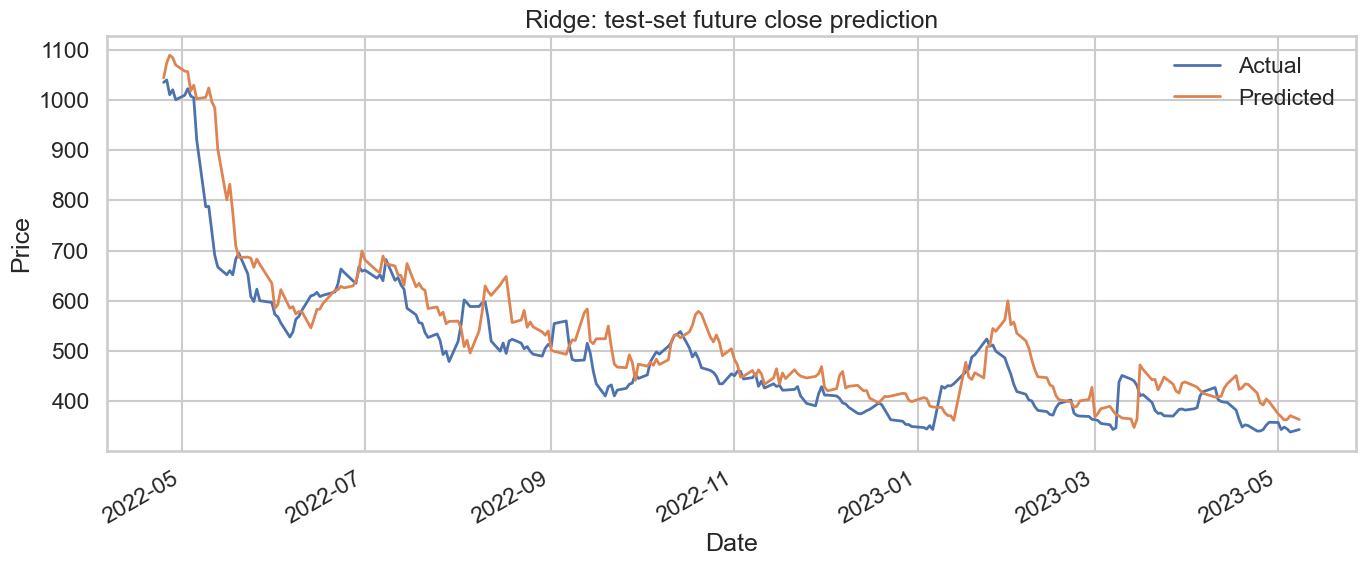

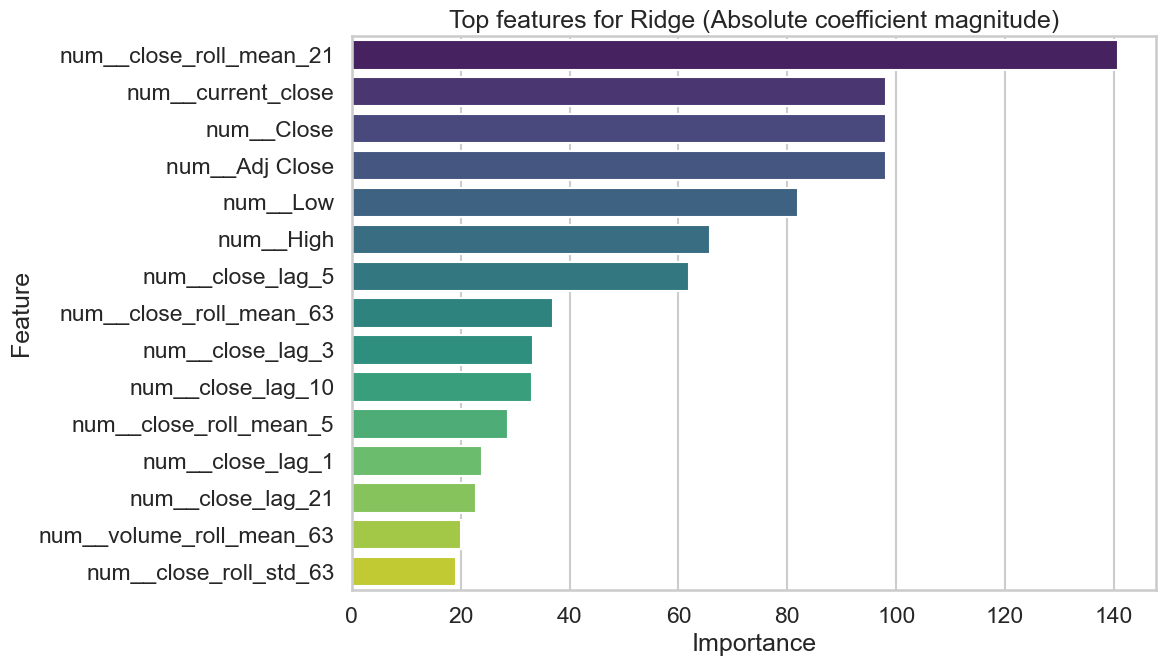

Artifacts saved in: C:\Users\tonne\Desktop\Data Science\Applied Machine Learning\Project\artifacts


In [34]:
best_model_name = comparison_df.loc[0, "Model"]
print(f"Best validation model: {best_model_name}")

X_train_full = pd.concat([X_train, X_valid])
y_train_full = pd.concat([y_train, y_valid])
close_train_full = pd.concat([close_train, close_valid])

best_pipeline = fitted_models[best_model_name]
best_pipeline.fit(X_train_full, y_train_full)

test_predictions = best_pipeline.predict(X_test)
test_metrics = regression_metrics(y_test, test_predictions, close_test)
test_results = pd.DataFrame([{"Model": best_model_name, "Split": "Test", **test_metrics}])
display(test_results)

prediction_frame = pd.DataFrame(
    {
        "Date": y_test.index,
        "Actual": y_test.values,
        "Predicted": test_predictions,
        "CurrentClose": close_test.values,
    }
).set_index("Date")

fig, ax = plt.subplots(figsize=(14, 6))
prediction_frame[["Actual", "Predicted"]].plot(ax=ax, linewidth=2)
ax.set_title(f"{best_model_name}: test-set future close prediction")
ax.set_ylabel("Price")
plt.tight_layout()
plt.savefig(ARTIFACTS_DIR / "02_test_predictions.png", dpi=200, bbox_inches="tight")
plt.show()

trained_feature_names = best_pipeline.named_steps["preprocessor"].get_feature_names_out()
estimator = best_pipeline.named_steps["model"]

if hasattr(estimator, "feature_importances_"):
    importance_values = estimator.feature_importances_
    importance_kind = "Model feature importance"
elif hasattr(estimator, "coef_"):
    importance_values = np.abs(np.ravel(estimator.coef_))
    importance_kind = "Absolute coefficient magnitude"
else:
    perm = permutation_importance(best_pipeline, X_test, y_test, n_repeats=10, random_state=RANDOM_STATE, n_jobs=-1)
    importance_values = perm.importances_mean
    importance_kind = "Permutation importance"

importance_df = (
    pd.DataFrame({"Feature": trained_feature_names, "Importance": importance_values})
    .sort_values("Importance", ascending=False)
    .head(15)
)

fig, ax = plt.subplots(figsize=(12, 7))
sns.barplot(data=importance_df, x="Importance", y="Feature", palette="viridis", ax=ax)
ax.set_title(f"Top features for {best_model_name} ({importance_kind})")
plt.tight_layout()
plt.savefig(ARTIFACTS_DIR / "03_feature_importance.png", dpi=200, bbox_inches="tight")
plt.show()

latest_features = X.iloc[[-1]]
forecast_date = latest_features.index[0] + BDay(FORECAST_HORIZON)
future_price_prediction = float(best_pipeline.predict(latest_features)[0])

future_prediction_df = pd.DataFrame(
    {
        "prediction_made_on": [latest_features.index[0]],
        "forecast_date": [forecast_date],
        "current_close": [float(model_data.loc[latest_features.index[0], "current_close"])],
        "predicted_close": [future_price_prediction],
        "forecast_horizon_days": [FORECAST_HORIZON],
        "ticker": [selected_ticker],
        "best_model": [best_model_name],
    }
)
future_prediction_df

comparison_df.to_csv(ARTIFACTS_DIR / "model_comparison.csv", index=False)
test_results.to_csv(ARTIFACTS_DIR / "test_metrics.csv", index=False)
prediction_frame.to_csv(ARTIFACTS_DIR / "test_predictions.csv")
future_prediction_df.to_csv(ARTIFACTS_DIR / "future_prediction.csv", index=False)
importance_df.to_csv(ARTIFACTS_DIR / "feature_importance.csv", index=False)
joblib.dump(best_pipeline, ARTIFACTS_DIR / "best_lumber_model.joblib")

summary_payload = {
    "ticker": selected_ticker,
    "forecast_horizon_days": FORECAST_HORIZON,
    "best_model": best_model_name,
    "validation_metrics": comparison_df.loc[0].to_dict(),
    "test_metrics": test_results.loc[0].to_dict(),
    "future_prediction": future_prediction_df.loc[0].to_dict(),
}

with open(ARTIFACTS_DIR / "run_summary.json", "w", encoding="utf-8") as file:
    json.dump(summary_payload, file, indent=2, default=str)

print("Artifacts saved in:", ARTIFACTS_DIR.resolve())

## 15. Extended Visual Diagnostics and Model Comparisons

This section adds extra charts for presentation:

- Validation metric comparison across all models
- Test metric comparison for top models
- Actual vs predicted scatter (parity) plots
- Residual distribution plots
- Metric heatmap and model rank view

These figures are useful for showing performance differences clearly in a report or presentation.

,Model,Split,MAE,RMSE,R2,MAPE,DirectionalAccuracy
0,SVR Tuned,Test,43.506607,58.876484,0.826647,0.087034,0.486590
1,SVR,Test,45.772185,62.590043,0.804089,0.094542,0.517241
2,Ridge,Test,49.963776,65.232899,0.787195,0.104569,0.475096
3,Lasso,Test,51.442593,66.483015,0.778961,0.107916,0.463602
4,Linear Regression,Test,51.686654,66.758514,0.777125,0.108291,0.459770
5,Gradient Boosting,Test,55.250055,77.839065,0.696999,0.107160,0.475096
6,Random Forest Tuned,Test,56.173323,77.910147,0.696446,0.108896,0.509579
7,Random Forest,Test,57.098833,79.812900,0.681438,0.110729,0.494253
8,Dummy Mean,Test,117.878972,148.044091,-0.096050,0.251803,0.498084


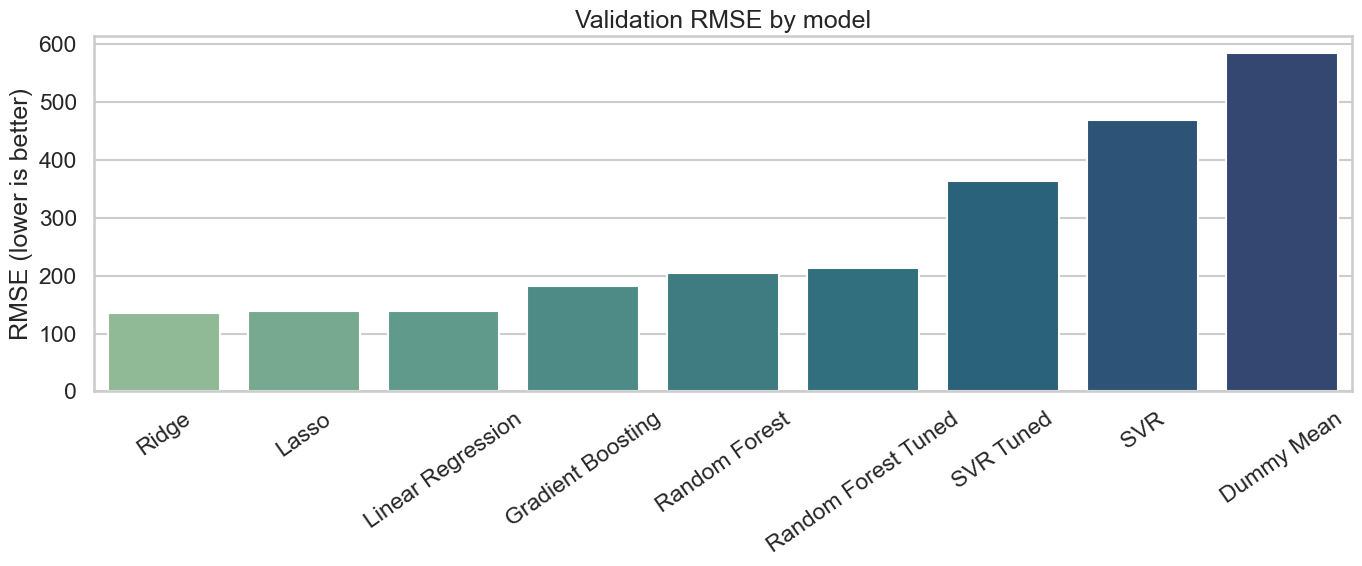

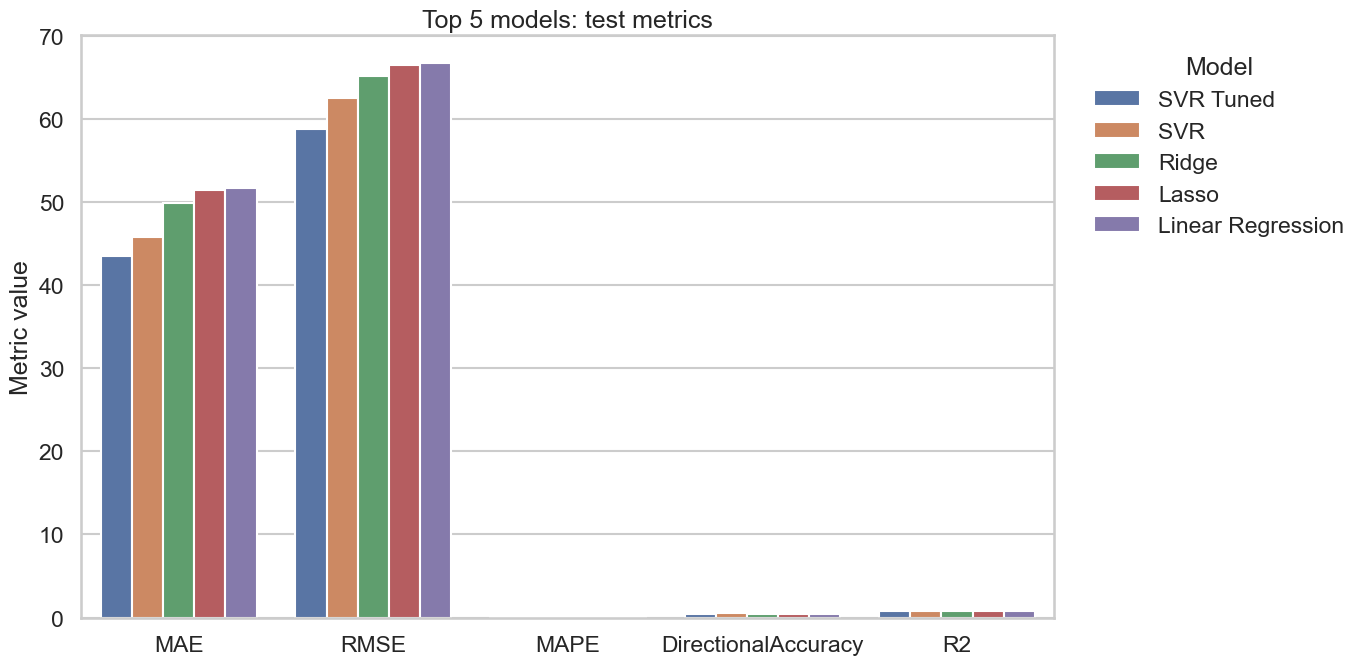

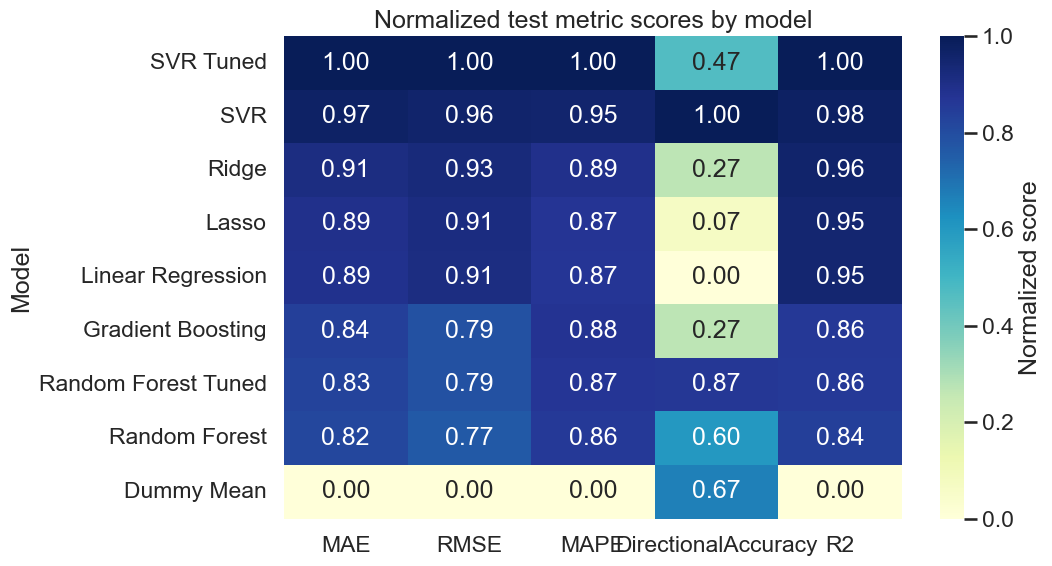

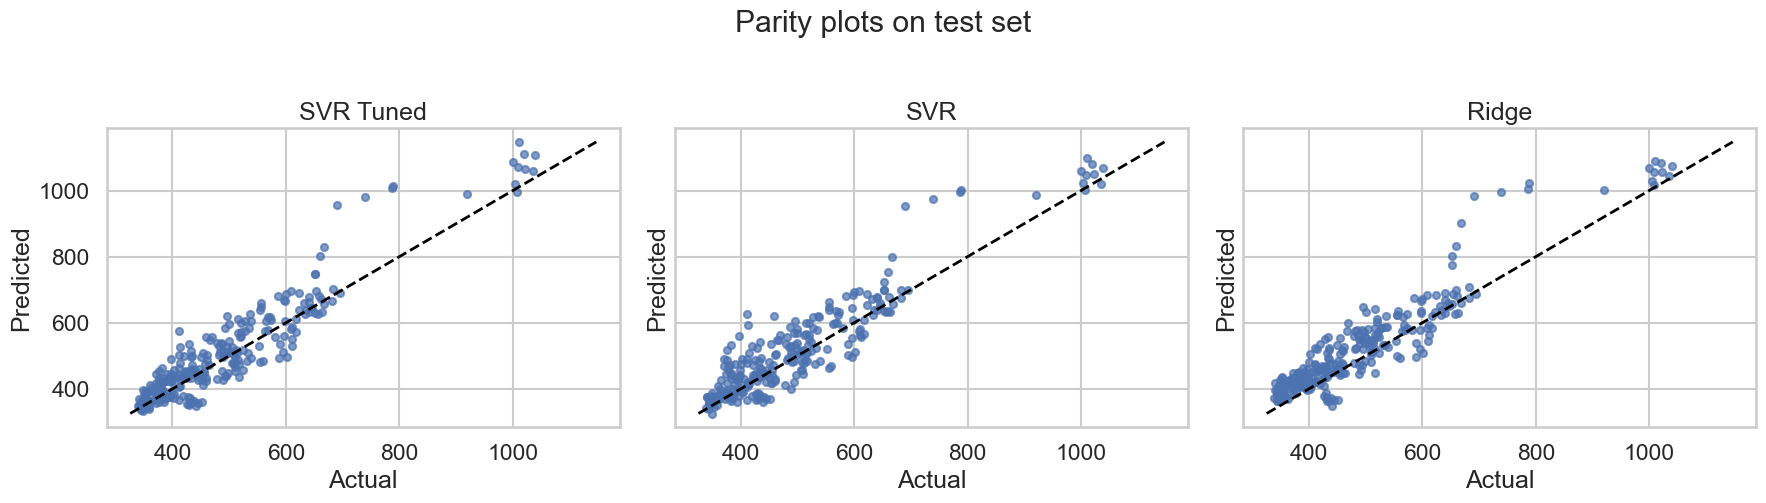

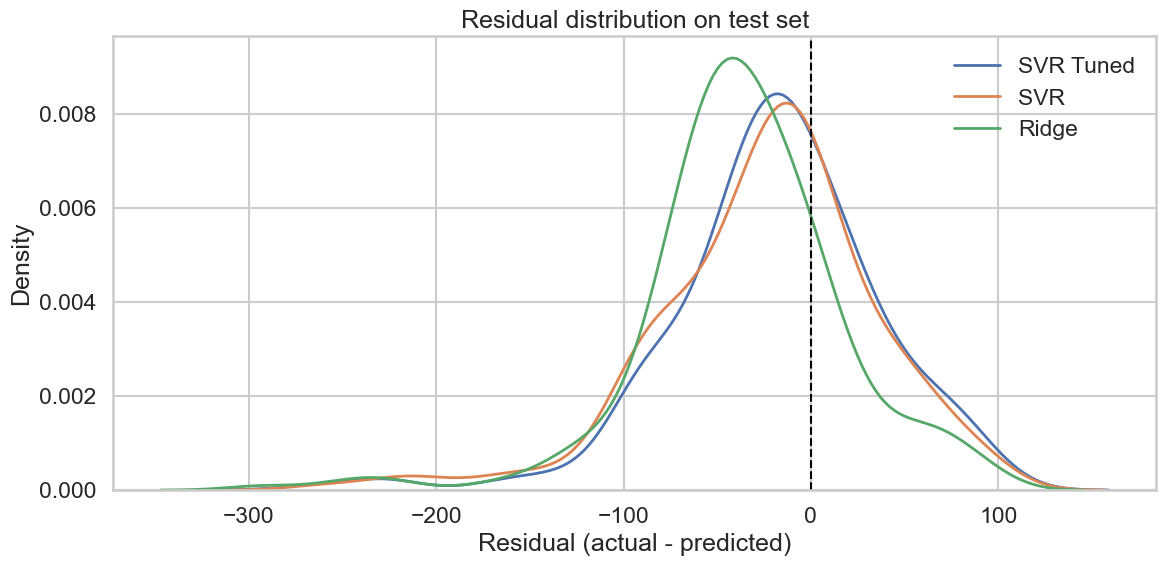

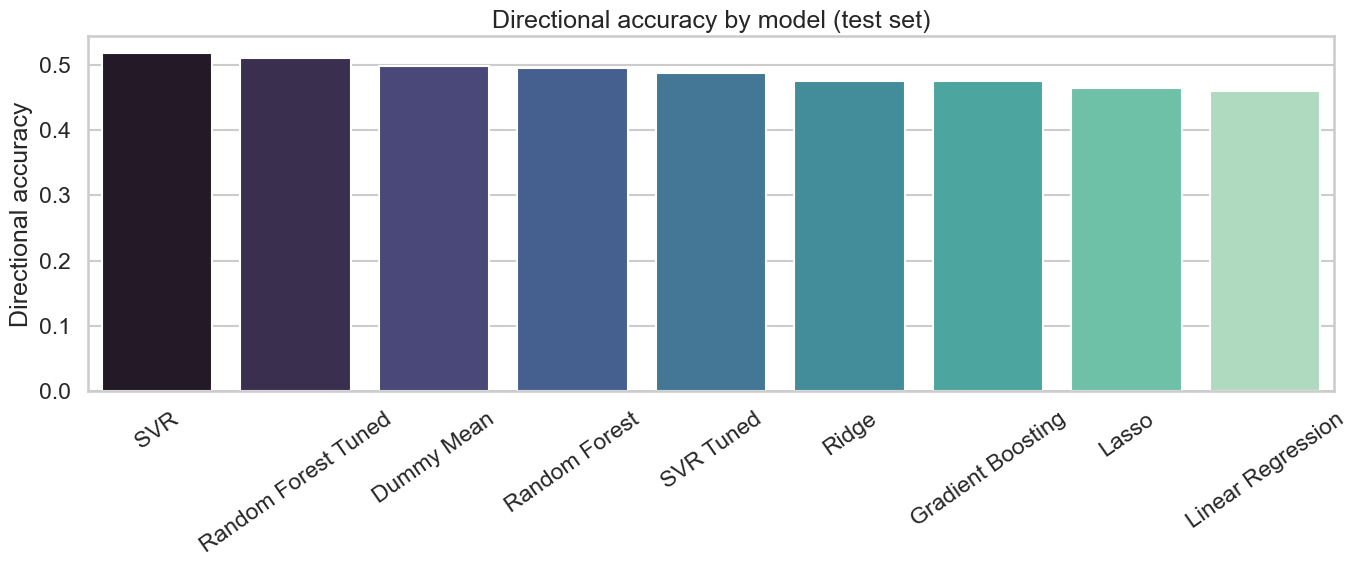

Extended comparison charts and table saved to artifacts folder.


In [35]:
# Refit each candidate on train+validation for a fair test comparison.
all_test_rows = []
all_test_predictions = {}

for model_name, pipeline in fitted_models.items():
    pipeline.fit(X_train_full, y_train_full)
    preds = pipeline.predict(X_test)
    all_test_predictions[model_name] = preds
    row = {"Model": model_name, "Split": "Test", **regression_metrics(y_test, preds, close_test)}
    all_test_rows.append(row)

all_test_df = pd.DataFrame(all_test_rows).sort_values(["RMSE", "MAE"]).reset_index(drop=True)
display(all_test_df)

# 1) Validation RMSE comparison for all models
val_plot_df = comparison_df.copy().sort_values("RMSE")
fig, ax = plt.subplots(figsize=(14, 6))
sns.barplot(data=val_plot_df, x="Model", y="RMSE", palette="crest", ax=ax)
ax.set_title("Validation RMSE by model")
ax.set_ylabel("RMSE (lower is better)")
ax.set_xlabel("")
ax.tick_params(axis="x", rotation=35)
plt.tight_layout()
plt.savefig(ARTIFACTS_DIR / "04_validation_rmse_comparison.png", dpi=220, bbox_inches="tight")
plt.show()

# 2) Multi-metric comparison for top models on test data
top_n = min(5, len(all_test_df))
top_test_df = all_test_df.head(top_n).copy()
top_test_long = top_test_df.melt(
    id_vars=["Model"],
    value_vars=["MAE", "RMSE", "MAPE", "DirectionalAccuracy", "R2"],
    var_name="Metric",
    value_name="Value",
)

fig, ax = plt.subplots(figsize=(14, 7))
sns.barplot(data=top_test_long, x="Metric", y="Value", hue="Model", ax=ax)
ax.set_title(f"Top {top_n} models: test metrics")
ax.set_ylabel("Metric value")
ax.set_xlabel("")
ax.legend(title="Model", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.savefig(ARTIFACTS_DIR / "05_top_models_test_metrics.png", dpi=220, bbox_inches="tight")
plt.show()

# 3) Heatmap of normalized test metrics (higher is better after transform)
heat = all_test_df.set_index("Model")[["MAE", "RMSE", "MAPE", "DirectionalAccuracy", "R2"]].copy()
normalized = pd.DataFrame(index=heat.index)
for col in ["MAE", "RMSE", "MAPE"]:
    normalized[col] = 1 - (heat[col] - heat[col].min()) / (heat[col].max() - heat[col].min() + 1e-12)
for col in ["DirectionalAccuracy", "R2"]:
    normalized[col] = (heat[col] - heat[col].min()) / (heat[col].max() - heat[col].min() + 1e-12)

fig, ax = plt.subplots(figsize=(11, 6))
sns.heatmap(normalized, annot=True, fmt=".2f", cmap="YlGnBu", cbar_kws={"label": "Normalized score"}, ax=ax)
ax.set_title("Normalized test metric scores by model")
plt.tight_layout()
plt.savefig(ARTIFACTS_DIR / "06_test_metric_heatmap.png", dpi=220, bbox_inches="tight")
plt.show()

# 4) Actual vs predicted (parity) plots for top 3 models
top_models_for_scatter = all_test_df["Model"].head(min(3, len(all_test_df))).tolist()
fig, axes = plt.subplots(1, len(top_models_for_scatter), figsize=(6 * len(top_models_for_scatter), 5), sharex=True, sharey=True)
if len(top_models_for_scatter) == 1:
    axes = [axes]

y_min = float(min(y_test.min(), min(np.min(all_test_predictions[m]) for m in top_models_for_scatter)))
y_max = float(max(y_test.max(), max(np.max(all_test_predictions[m]) for m in top_models_for_scatter)))

for ax, model_name in zip(axes, top_models_for_scatter):
    preds = all_test_predictions[model_name]
    ax.scatter(y_test, preds, alpha=0.7, s=26)
    ax.plot([y_min, y_max], [y_min, y_max], linestyle="--", linewidth=2, color="black")
    ax.set_title(model_name)
    ax.set_xlabel("Actual")
    ax.set_ylabel("Predicted")

fig.suptitle("Parity plots on test set", y=1.02)
plt.tight_layout()
plt.savefig(ARTIFACTS_DIR / "07_parity_plots_top_models.png", dpi=220, bbox_inches="tight")
plt.show()

# 5) Residual distributions for top 3 models
fig, ax = plt.subplots(figsize=(12, 6))
for model_name in top_models_for_scatter:
    residuals = y_test.to_numpy() - all_test_predictions[model_name]
    sns.kdeplot(residuals, fill=False, linewidth=2, label=model_name, ax=ax)
ax.axvline(0, linestyle="--", linewidth=1.5, color="black")
ax.set_title("Residual distribution on test set")
ax.set_xlabel("Residual (actual - predicted)")
ax.set_ylabel("Density")
ax.legend()
plt.tight_layout()
plt.savefig(ARTIFACTS_DIR / "08_residual_distribution_top_models.png", dpi=220, bbox_inches="tight")
plt.show()

# 6) Directional accuracy comparison on test data
fig, ax = plt.subplots(figsize=(14, 6))
dir_df = all_test_df.sort_values("DirectionalAccuracy", ascending=False)
sns.barplot(data=dir_df, x="Model", y="DirectionalAccuracy", palette="mako", ax=ax)
ax.set_title("Directional accuracy by model (test set)")
ax.set_ylabel("Directional accuracy")
ax.set_xlabel("")
ax.tick_params(axis="x", rotation=35)
plt.tight_layout()
plt.savefig(ARTIFACTS_DIR / "09_directional_accuracy_comparison.png", dpi=220, bbox_inches="tight")
plt.show()

# Save detailed table for the new comparison section.
all_test_df.to_csv(ARTIFACTS_DIR / "all_models_test_metrics.csv", index=False)
print("Extended comparison charts and table saved to artifacts folder.")

## 16. Metric Explanations and How to Read the Results

If these metrics are new to you, use this section as a quick guide.

### Why we have Train, Validation, and Test

- Train set: used to fit the model parameters.
- Validation set: used to compare models and tune hyperparameters.
- Test set: untouched final check of performance on unseen data.

This is important because a model can look great on training data but fail on unseen data. Validation and test scores tell us whether the model generalizes.

### What each metric means

- MAE (Mean Absolute Error): average absolute prediction error in price units.
  - Example: MAE = 50 means predictions are off by about 50 price points on average.
  - Lower is better.

- RMSE (Root Mean Squared Error): similar to MAE but penalizes big mistakes more.
  - Useful when large forecasting errors are especially costly.
  - Lower is better.

- MAPE (Mean Absolute Percentage Error): average error in percentage terms.
  - Example: MAPE = 0.10 means about 10 percent average error.
  - Lower is better.

- R2: proportion of variance in the target explained by the model.
  - 1.0 is perfect, 0 means no improvement over simple mean-level explanation, negative means poor fit.
  - Higher is better.

- DirectionalAccuracy: how often the model predicts the correct direction (up or down) versus current price.
  - Useful if you care about movement direction, not only exact price level.
  - Higher is better.

### How to compare models

- If your goal is accurate price level forecasts, prioritize RMSE and MAE.
- If your goal is calling up/down moves, prioritize DirectionalAccuracy.
- A practical model should perform well on both value error metrics and directional behavior.
- Always trust test results more than validation results for final conclusions.

In [36]:
# Plain-language interpretation of this notebook's latest results.
if "all_test_df" in globals() and not all_test_df.empty:
    ranking = all_test_df.sort_values("RMSE").reset_index(drop=True)
    best_rmse_row = ranking.iloc[0]
    best_dir_row = all_test_df.sort_values("DirectionalAccuracy", ascending=False).iloc[0]

    print("RESULT INTERPRETATION")
    print("=" * 80)
    print(f"Best model by RMSE (price accuracy): {best_rmse_row['Model']}")
    print(f"  RMSE: {best_rmse_row['RMSE']:.2f}")
    print(f"  MAE : {best_rmse_row['MAE']:.2f}")
    print(f"  MAPE: {best_rmse_row['MAPE'] * 100:.2f}%")
    print(f"  R2  : {best_rmse_row['R2']:.3f}")
    print(f"  Directional accuracy: {best_rmse_row['DirectionalAccuracy'] * 100:.2f}%")
    print()

    print(f"Best model by directional accuracy: {best_dir_row['Model']}")
    print(f"  Directional accuracy: {best_dir_row['DirectionalAccuracy'] * 100:.2f}%")
    print(f"  RMSE: {best_dir_row['RMSE']:.2f} | MAE: {best_dir_row['MAE']:.2f}")
    print()

    if best_rmse_row["Model"] == best_dir_row["Model"]:
        print("Interpretation: the same model is strongest on both price accuracy and direction.")
    else:
        print("Interpretation: there is a trade-off.")
        print("- One model is best for exact price forecasting (lowest RMSE).")
        print("- Another model is best for predicting up/down direction.")

    # Relative gain versus naive baseline.
    baseline = all_test_df.loc[all_test_df["Model"] == "Dummy Mean"]
    if not baseline.empty:
        baseline_rmse = float(baseline.iloc[0]["RMSE"])
        improvement = (baseline_rmse - float(best_rmse_row["RMSE"])) / baseline_rmse * 100
        print()
        print(f"Improvement vs Dummy Mean baseline in RMSE: {improvement:.2f}%")

    print("=" * 80)
else:
    print("Run the extended comparison section first so all_test_df is available.")

RESULT INTERPRETATION
Best model by RMSE (price accuracy): SVR Tuned
  RMSE: 58.88
  MAE : 43.51
  MAPE: 8.70%
  R2  : 0.827
  Directional accuracy: 48.66%

Best model by directional accuracy: SVR
  Directional accuracy: 51.72%
  RMSE: 62.59 | MAE: 45.77

Interpretation: there is a trade-off.
- One model is best for exact price forecasting (lowest RMSE).
- Another model is best for predicting up/down direction.

Improvement vs Dummy Mean baseline in RMSE: 60.23%


## 17. Extended Prediction Timeline (Including Pre-May 2022)

These plots focus on historical context and forecast behavior over a longer timeline.

- Full-history close price with train/validation/test split markers
- Validation and test predictions overlaid on historical prices (starts before May 2022)
- Rolling MAE to show how forecast error changes over time
- Cumulative absolute error to compare model stability over the test period

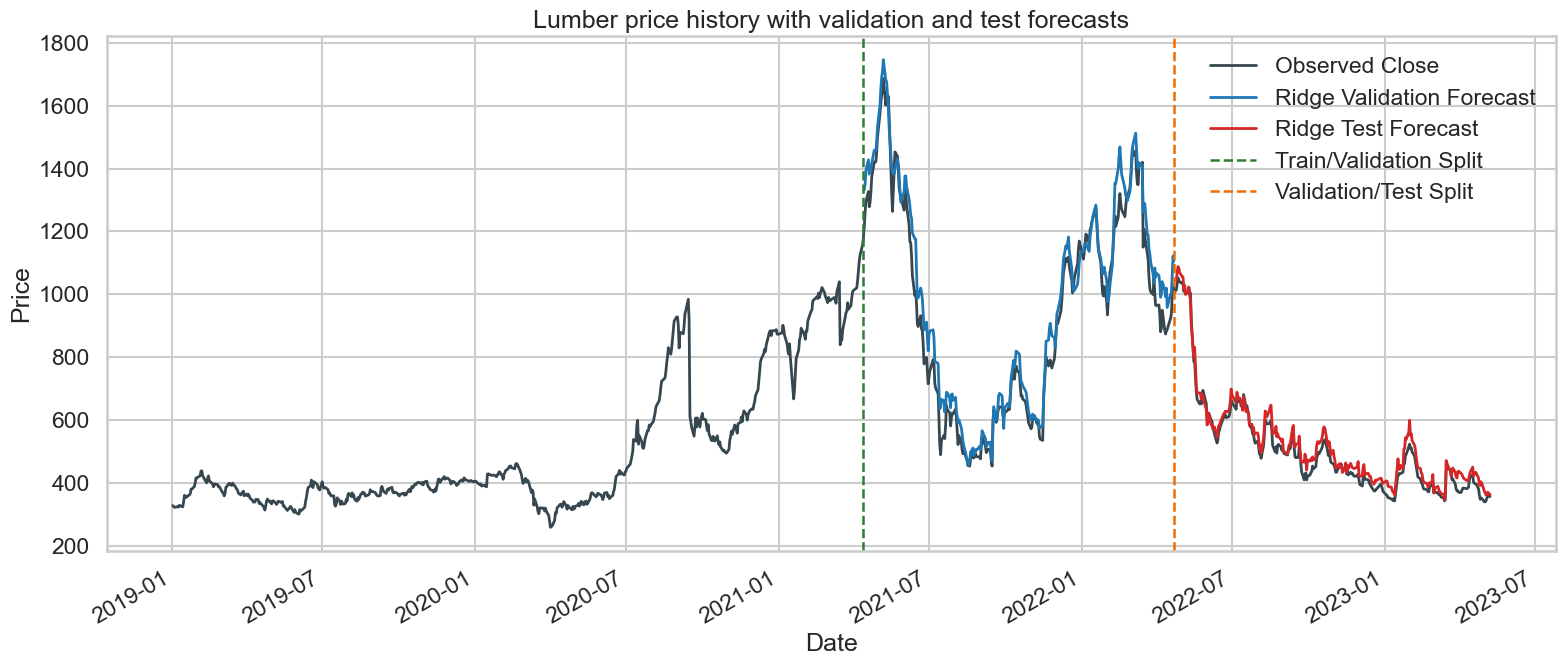

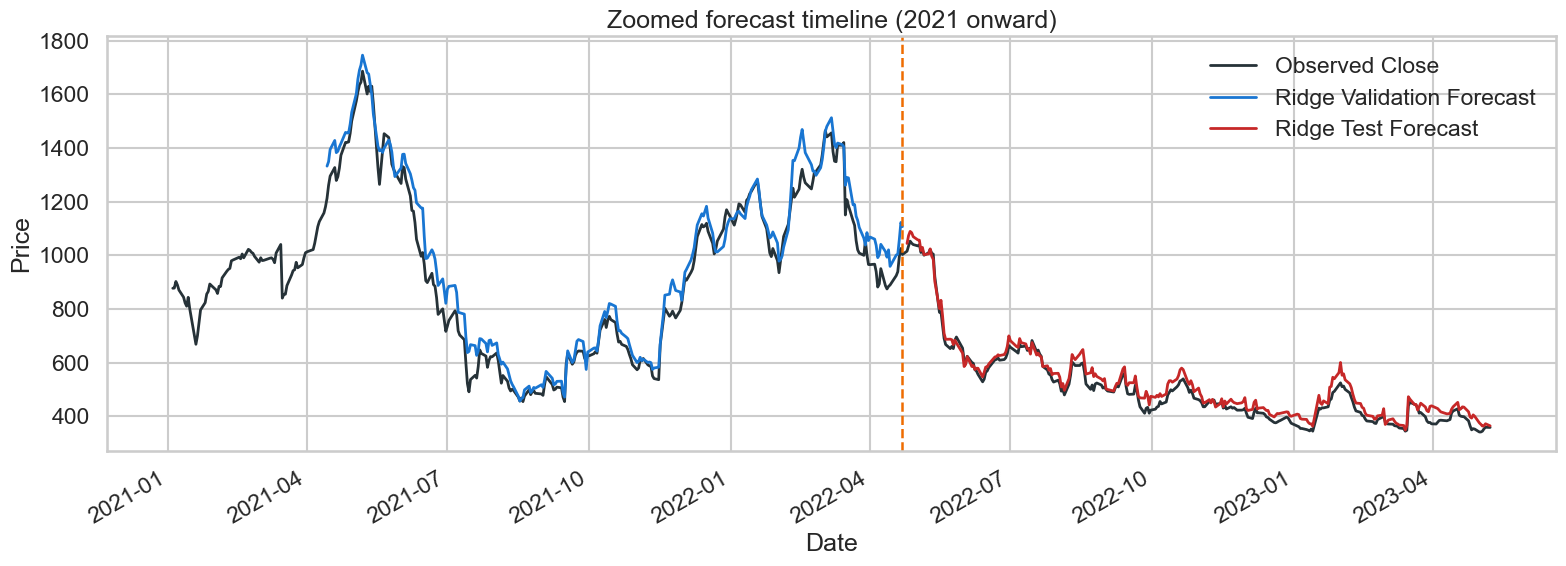

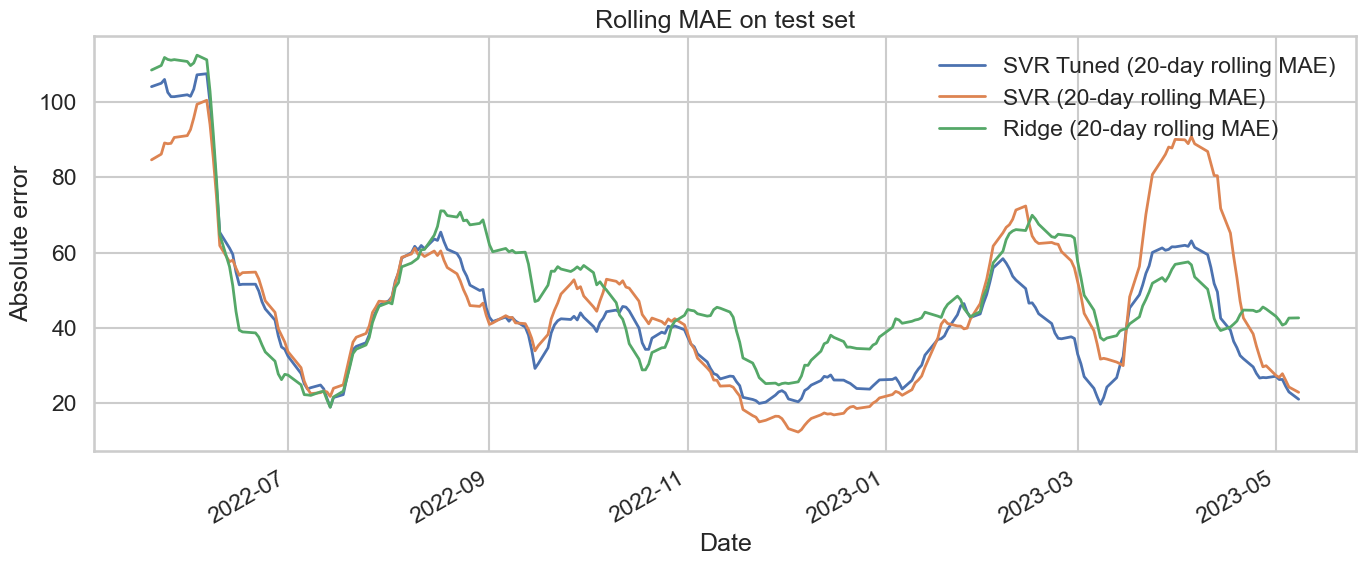

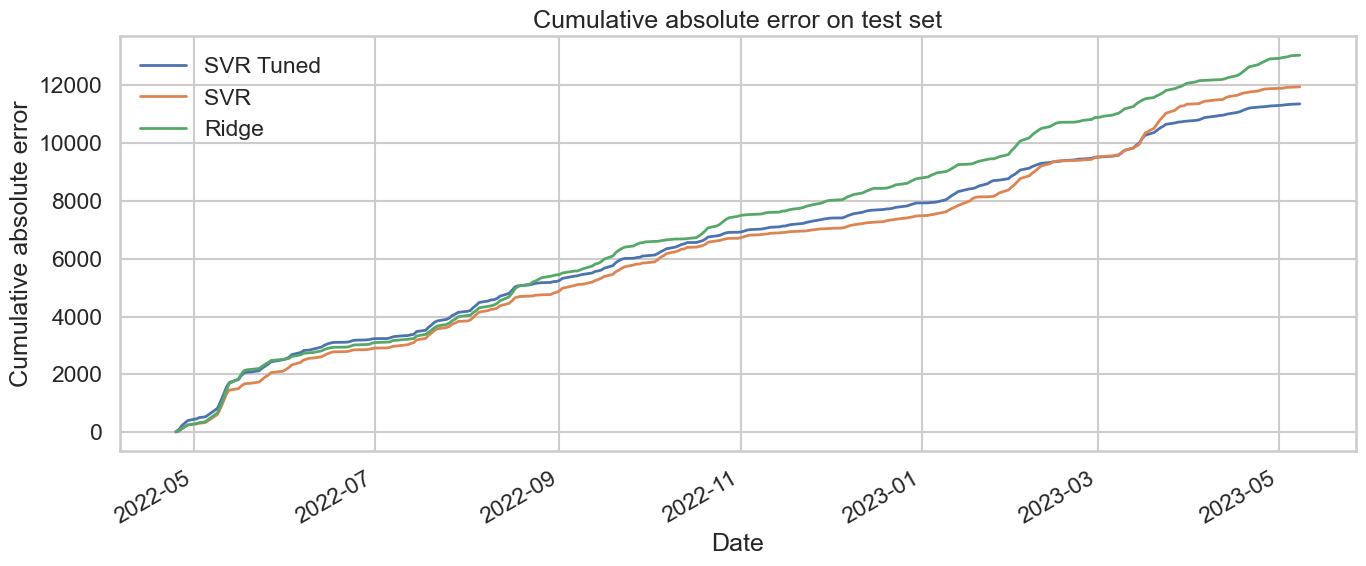

Saved extended timeline plots: 10-13 in artifacts folder.


In [37]:
# Build long-history views for the model selected in section 11-14.
if best_model_name in validation_predictions:
    best_valid_preds = validation_predictions[best_model_name]
else:
    best_valid_preds = fitted_models[best_model_name].fit(X_train, y_train).predict(X_valid)

valid_prediction_frame = pd.DataFrame(
    {
        "Date": y_valid.index,
        "ActualFutureClose": y_valid.values,
        "PredictedFutureClose": best_valid_preds,
        "CurrentClose": close_valid.values,
    }
).set_index("Date")

test_prediction_frame = pd.DataFrame(
    {
        "Date": y_test.index,
        "ActualFutureClose": y_test.values,
        "PredictedFutureClose": test_predictions,
        "CurrentClose": close_test.values,
    }
).set_index("Date")

history_start = pd.Timestamp("2019-01-01")
split_train_end = X_train.index[-1]
split_valid_end = X_valid.index[-1]

# 1) Long history with split markers and forecast overlays (pre-May 2022 included)
fig, ax = plt.subplots(figsize=(16, 7))
model_data.loc[history_start:, "current_close"].plot(ax=ax, color="#37474f", linewidth=2.0, label="Observed Close")
valid_prediction_frame.loc[history_start:, "PredictedFutureClose"].plot(
    ax=ax, color="#1f77b4", linewidth=2.0, label=f"{best_model_name} Validation Forecast"
)
test_prediction_frame["PredictedFutureClose"].plot(
    ax=ax, color="#d62728", linewidth=2.0, label=f"{best_model_name} Test Forecast"
)
ax.axvline(split_train_end, color="#2e7d32", linestyle="--", linewidth=1.8, label="Train/Validation Split")
ax.axvline(split_valid_end, color="#ef6c00", linestyle="--", linewidth=1.8, label="Validation/Test Split")
ax.set_title("Lumber price history with validation and test forecasts")
ax.set_ylabel("Price")
ax.legend(loc="upper right")
plt.tight_layout()
plt.savefig(ARTIFACTS_DIR / "10_history_with_predictions.png", dpi=220, bbox_inches="tight")
plt.show()

# 2) Zoomed view around the 2021-2023 regime change
zoom_start = pd.Timestamp("2021-01-01")
fig, ax = plt.subplots(figsize=(16, 6))
model_data.loc[zoom_start:, "current_close"].plot(ax=ax, color="#263238", linewidth=2.0, label="Observed Close")
valid_prediction_frame.loc[zoom_start:, "PredictedFutureClose"].plot(
    ax=ax, color="#1976d2", linewidth=2.0, label=f"{best_model_name} Validation Forecast"
)
test_prediction_frame["PredictedFutureClose"].plot(
    ax=ax, color="#c62828", linewidth=2.0, label=f"{best_model_name} Test Forecast"
)
ax.axvline(split_valid_end, color="#ef6c00", linestyle="--", linewidth=1.8)
ax.set_title("Zoomed forecast timeline (2021 onward)")
ax.set_ylabel("Price")
ax.legend(loc="upper right")
plt.tight_layout()
plt.savefig(ARTIFACTS_DIR / "11_zoomed_history_predictions_2021_onward.png", dpi=220, bbox_inches="tight")
plt.show()

# 3) Rolling MAE over test dates for top models
top_models_for_rolling = all_test_df["Model"].head(min(3, len(all_test_df))).tolist()
rolling_window = 20
fig, ax = plt.subplots(figsize=(14, 6))
for model_name in top_models_for_rolling:
    abs_error = np.abs(y_test.to_numpy() - all_test_predictions[model_name])
    rolling_mae = pd.Series(abs_error, index=y_test.index).rolling(rolling_window).mean()
    rolling_mae.plot(ax=ax, linewidth=2, label=f"{model_name} ({rolling_window}-day rolling MAE)")
ax.set_title("Rolling MAE on test set")
ax.set_ylabel("Absolute error")
ax.set_xlabel("Date")
ax.legend(loc="upper right")
plt.tight_layout()
plt.savefig(ARTIFACTS_DIR / "12_rolling_mae_top_models.png", dpi=220, bbox_inches="tight")
plt.show()

# 4) Cumulative absolute error comparison
fig, ax = plt.subplots(figsize=(14, 6))
for model_name in top_models_for_rolling:
    cum_abs_error = np.cumsum(np.abs(y_test.to_numpy() - all_test_predictions[model_name]))
    pd.Series(cum_abs_error, index=y_test.index).plot(ax=ax, linewidth=2, label=model_name)
ax.set_title("Cumulative absolute error on test set")
ax.set_ylabel("Cumulative absolute error")
ax.set_xlabel("Date")
ax.legend(loc="upper left")
plt.tight_layout()
plt.savefig(ARTIFACTS_DIR / "13_cumulative_absolute_error_top_models.png", dpi=220, bbox_inches="tight")
plt.show()

print("Saved extended timeline plots: 10-13 in artifacts folder.")

## 18. One-Year Forward Forecast Scenario

This section projects lumber prices for roughly one business year ahead using recursive forecasting.

Because the model was trained to predict the close price $h$ business days ahead (with $h=5$), we generate a forward path in 5-business-day steps and then interpolate to business-daily points for visualization.

### Important assumptions

- Future external features (if any) are held constant at their latest known values.
- Future volume is approximated by the recent rolling average.
- Open/High/Low/Adj Close for synthetic future rows are set equal to the predicted close.

This is a scenario forecast, not a guaranteed market path.

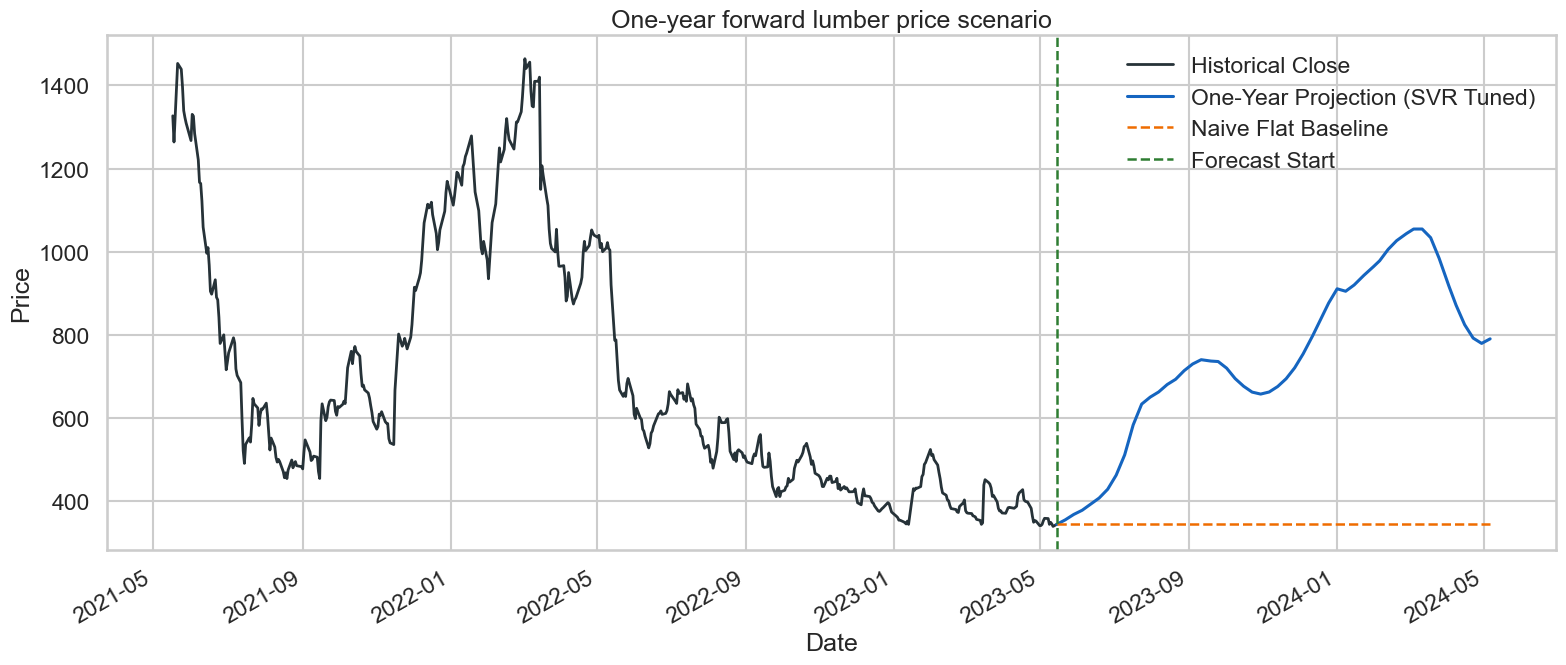

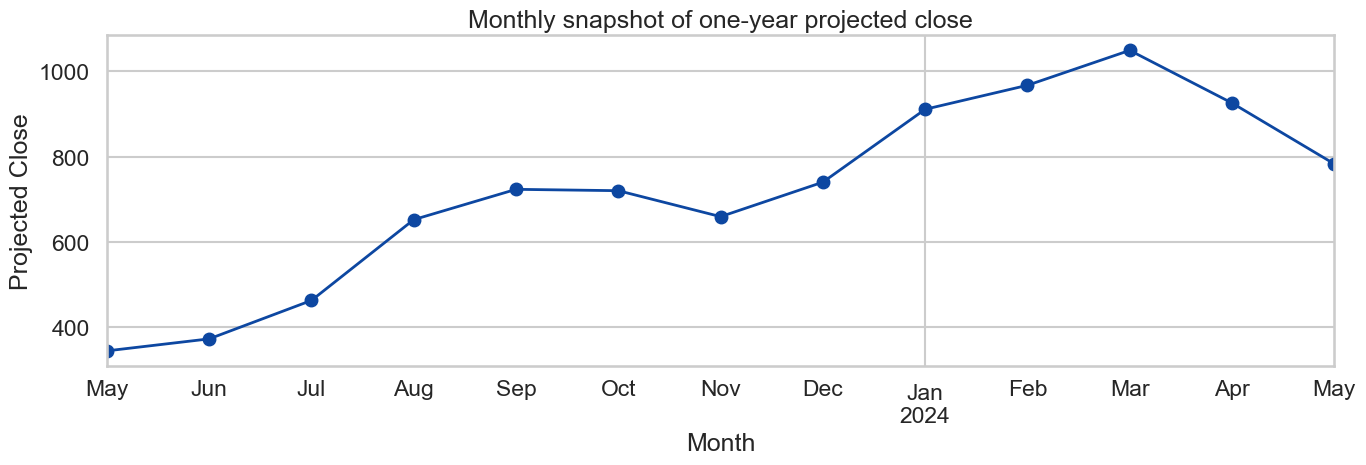

Projection model: SVR Tuned
Projection starts at: 2023-05-15
Projection ends at: 2024-05-06
Projected close at end of horizon: 790.39
Saved one-year projection plots and CSV outputs in artifacts folder.


In [38]:
# Choose a forecasting model for long-horizon projection.
# Prefer best test-RMSE model from all_test_df when available.
if "all_test_df" in globals() and not all_test_df.empty:
    forecast_model_name = all_test_df.sort_values("RMSE").iloc[0]["Model"]
else:
    forecast_model_name = best_model_name

forecast_model = fitted_models[forecast_model_name]
forecast_model.fit(X, y)

# Feature engineering for inference (same logic as build_features, without target shift).
def build_features_for_inference(data: pd.DataFrame) -> pd.DataFrame:
    frame = data.copy()

    for lag in [1, 2, 3, 5, 10, 21]:
        frame[f"close_lag_{lag}"] = frame["Close"].shift(lag)
        frame[f"volume_lag_{lag}"] = frame["Volume"].shift(lag)
        frame[f"return_lag_{lag}"] = frame["Close"].pct_change(lag)

    for window in [5, 10, 21, 63]:
        frame[f"close_roll_mean_{window}"] = frame["Close"].rolling(window).mean()
        frame[f"close_roll_std_{window}"] = frame["Close"].rolling(window).std()
        frame[f"volume_roll_mean_{window}"] = frame["Volume"].rolling(window).mean()
        frame[f"momentum_{window}"] = frame["Close"] / frame["Close"].shift(window) - 1

    frame["daily_return"] = frame["Close"].pct_change()
    frame["intraday_range"] = (frame["High"] - frame["Low"]) / frame["Close"]
    frame["open_close_change"] = (frame["Close"] - frame["Open"]) / frame["Open"]
    frame["volatility_10"] = frame["daily_return"].rolling(10).std()
    frame["volatility_21"] = frame["daily_return"].rolling(21).std()
    frame["month"] = frame.index.month
    frame["quarter"] = frame.index.quarter
    frame["day_of_week"] = frame.index.dayofweek
    frame["day_of_year"] = frame.index.dayofyear
    frame["is_month_end"] = frame.index.is_month_end.astype(int)
    frame["current_close"] = frame["Close"]

    frame = frame.replace([np.inf, -np.inf], np.nan)
    return frame


business_days_ahead = 252
step_days = FORECAST_HORIZON
n_steps = int(np.ceil(business_days_ahead / step_days))

sim_columns_base = ["Open", "High", "Low", "Close", "Adj Close", "Volume"]
extra_columns = [col for col in dataset.columns if col not in sim_columns_base]
sim_columns = sim_columns_base + extra_columns

sim_data = dataset[sim_columns].copy()
last_known_date = sim_data.index[-1]

future_rows = []
for _ in range(n_steps):
    inference_frame = build_features_for_inference(sim_data)
    feature_row = inference_frame.iloc[[-1]][feature_columns]
    predicted_close = float(forecast_model.predict(feature_row)[0])

    future_date = sim_data.index[-1] + BDay(step_days)
    recent_volume = float(sim_data["Volume"].tail(21).mean())

    synthetic_row = {column: np.nan for column in sim_columns}
    synthetic_row["Open"] = predicted_close
    synthetic_row["High"] = predicted_close
    synthetic_row["Low"] = predicted_close
    synthetic_row["Close"] = predicted_close
    synthetic_row["Adj Close"] = predicted_close
    synthetic_row["Volume"] = recent_volume

    # Hold optional exogenous features constant at latest known values.
    for column in extra_columns:
        synthetic_row[column] = float(sim_data[column].ffill().iloc[-1]) if pd.notna(sim_data[column].ffill().iloc[-1]) else 0.0

    sim_data.loc[future_date] = synthetic_row
    future_rows.append({"Date": future_date, "PredictedClose": predicted_close})

one_year_projection = pd.DataFrame(future_rows).set_index("Date").sort_index()

# Build business-daily interpolated projection for cleaner charting.
projection_daily_index = pd.bdate_range(start=last_known_date, end=one_year_projection.index[-1])
projection_path = pd.concat(
    [pd.Series([float(dataset["Close"].iloc[-1])], index=[last_known_date], name="PredictedClose"), one_year_projection["PredictedClose"]]
).sort_index()
projection_daily = projection_path.reindex(projection_daily_index).interpolate(method="time")

# Naive baseline: flat continuation from latest close.
naive_daily = pd.Series(float(dataset["Close"].iloc[-1]), index=projection_daily_index)

# Plot 1: Last 2 years history + one-year forward projection.
history_window_start = dataset.index[-1] - pd.DateOffset(years=2)
fig, ax = plt.subplots(figsize=(16, 7))
dataset.loc[history_window_start:, "Close"].plot(ax=ax, color="#263238", linewidth=2.0, label="Historical Close")
projection_daily.plot(ax=ax, color="#1565c0", linewidth=2.2, label=f"One-Year Projection ({forecast_model_name})")
naive_daily.plot(ax=ax, color="#ef6c00", linewidth=1.8, linestyle="--", label="Naive Flat Baseline")
ax.axvline(dataset.index[-1], color="#2e7d32", linestyle="--", linewidth=1.8, label="Forecast Start")
ax.set_title("One-year forward lumber price scenario")
ax.set_ylabel("Price")
ax.legend(loc="upper right")
plt.tight_layout()
plt.savefig(ARTIFACTS_DIR / "14_one_year_projection.png", dpi=220, bbox_inches="tight")
plt.show()

# Plot 2: Monthly snapshots of projected path.
monthly_projection = projection_daily.resample("MS").first()
fig, ax = plt.subplots(figsize=(14, 5))
monthly_projection.plot(ax=ax, marker="o", linewidth=2.0, color="#0d47a1")
ax.set_title("Monthly snapshot of one-year projected close")
ax.set_ylabel("Projected Close")
ax.set_xlabel("Month")
plt.tight_layout()
plt.savefig(ARTIFACTS_DIR / "15_one_year_projection_monthly.png", dpi=220, bbox_inches="tight")
plt.show()

# Export projection outputs for reporting.
one_year_projection.to_csv(ARTIFACTS_DIR / "one_year_projection_stepwise.csv")
projection_daily.to_frame(name="PredictedClose").to_csv(ARTIFACTS_DIR / "one_year_projection_daily.csv")

print(f"Projection model: {forecast_model_name}")
print(f"Projection starts at: {dataset.index[-1].date()}")
print(f"Projection ends at: {projection_daily.index[-1].date()}")
print(f"Projected close at end of horizon: {projection_daily.iloc[-1]:.2f}")
print("Saved one-year projection plots and CSV outputs in artifacts folder.")